# Week 8 Lab Exercise — ARIA v5.0: The Matai'an Three-Act Auditor
# 第八週課堂練習 — ARIA v5.0：馬太鞍三幕稽核器

**Guided lab worksheet** — follow along with the instructor's Demo notebook and fill in the TODO cells.
**引導式練習** — 跟著老師的 Demo 操作，完成 TODO 標記的程式碼。

**Case / 案例**: 2025 Matai'an Creek Barrier Lake Event（馬太鞍溪堰塞湖事件）

---

### Class rhythm / 課程節奏

| Phase / 階段 | Content / 內容 | Cells | Time / 時間 |
|---|---|---|---|
| **Lab 1** | Spectral Detective 光譜偵探 | [S1]–[S6] | 35 min |
| **Lab 2** | Three-Act Audit 三幕稽核 | [S7]–[S15] | 50 min |


## Lab 1 — Environment + Three-Act STAC Scene Selection
## Lab 1 — 環境設定 + 三幕 STAC 影像選擇


In [ ]:
# [S1] Environment setup — fill in the imports and STAC client

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd

import pystac_client
import planetary_computer as pc
import stackstac
import rioxarray as rxr

from shapely.geometry import Point
from pyproj import Transformer

# Microsoft JhengHei for Chinese labels
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "PingFang TC", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

# Connect to Planetary Computer
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

def robust_search(bbox, datetime_range, cloud_max=30, max_items=60, tries=3):
    for attempt in range(tries):
        try:
            search = catalog.search(
                collections=["sentinel-2-l2a"],
                bbox=bbox,
                datetime=datetime_range,
                max_items=max_items,
            )
            items = list(search.items())
            items = [i for i in items if i.properties.get("eo:cloud_cover", 100) < cloud_max]
            items.sort(key=lambda i: i.properties.get("eo:cloud_cover", 100))
            return items
        except Exception:
            time.sleep(2 ** attempt)
    raise RuntimeError("STAC search failed 3x")

# AOI — Matai'an catchment (upper Wanrong → downstream Guangfu)
MATAIAN_BBOX = [121.28, 23.56, 121.52, 23.76]
WANTED_BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]

# Fill these after QA if you want reproducible scene IDs
PRE_ITEM_ID  = "FILL_IN_AFTER_QA"
MID_ITEM_ID  = "FILL_IN_AFTER_QA"
POST_ITEM_ID = "FILL_IN_AFTER_QA"


Pre-event candidates: 1


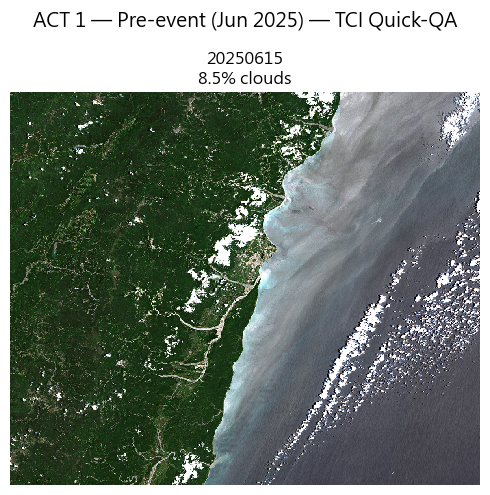


→ Selected Pre-event scene: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417


In [2]:
# Cell [2] — ACT 1: Pre-event baseline (Jun 2025, before Typhoon Wipha)
# ── Cell [2] — 第一幕：事件前基線影像（2025/6，薇帕颱風之前）
items_pre = robust_search(
    bbox=MATAIAN_BBOX,
    datetime_range="2025-06-01/2025-07-15",
    cloud_max=20,
    max_items=20,   # Sentinel-2 revisit ~3d → ~15 items in 45d, 20 is plenty
                    # ── Sentinel-2 重訪週期約 3 天，45 天區間最多 ~15 張，20 張夠用
)
print(f"Pre-event candidates: {len(items_pre)}")

# TCI Quick-QA — preview up to 3 least-cloudy scenes (handles <3 gracefully)
# ── TCI 目視品管：預覽前 3 張雲量最少的影像（少於 3 張也能正常處理）
candidates_pre = items_pre[:3]
n = max(len(candidates_pre), 1)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]
for ax, item in zip(axes, candidates_pre):
    tci = rxr.open_rasterio(item.assets["visual"].href, overview_level=3)
    tci.plot.imshow(ax=ax)
    ax.set_title(f"{item.id[11:19]}\n{item.properties['eo:cloud_cover']:.1f}% clouds")
    ax.axis("off")
plt.suptitle("ACT 1 — Pre-event (Jun 2025) — TCI Quick-QA", fontsize=14)
plt.tight_layout()
plt.show()

pre_item = candidates_pre[0]
print(f"\n→ Selected Pre-event scene: {pre_item.id}")

### ✏️ Discussion / 討論（Act 1 — Pre）
Why did you pick this Pre-event scene? Consider cloud cover **over the Matai'an valley** specifically.
為什麼選這張事件前影像？特別注意馬太鞍谷地上方的雲量（不只是 tile 整體數字）。

*(Write 1-2 sentences here / 寫 1-2 句)*


因為這張影像馬太鞍谷地本身大致無雲，能清楚看到上游谷地與周圍森林。提供較乾淨的基準面，適合後續變遷比較。

Mid-event candidates: 7


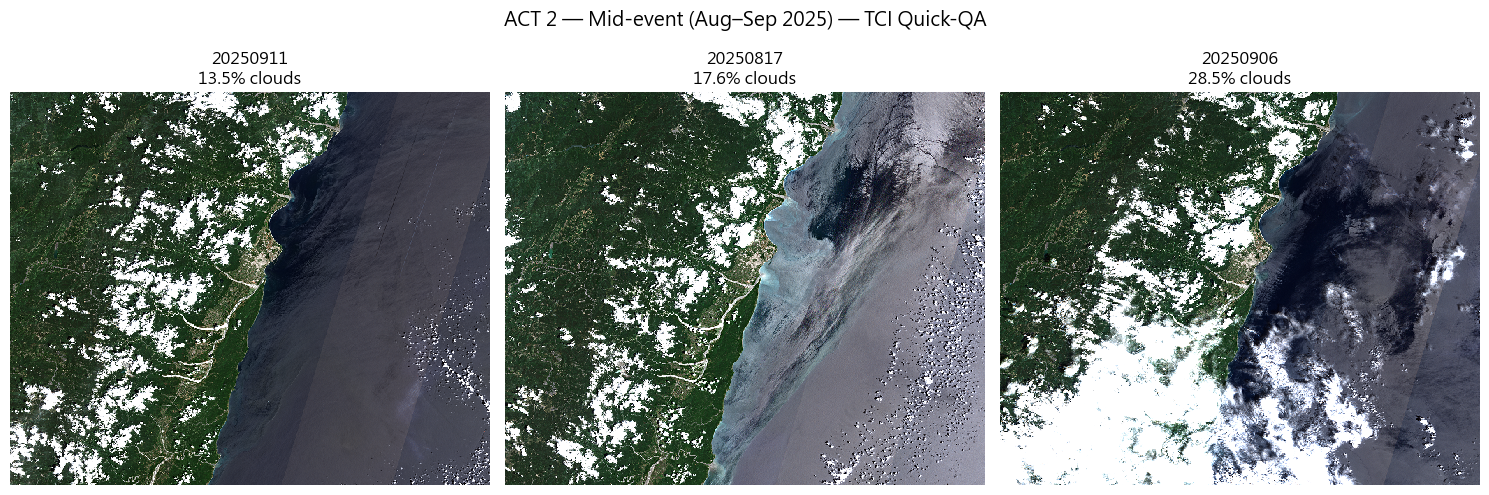


→ Selected Mid-event scene: S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
→ MID_ITEM_ID = S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914


In [3]:
# [S3] ACT 2 — Mid-event STAC search (Aug–Sep 2025, barrier lake present, before Sep 23 breach)
# ── 第二幕：事件中期影像搜尋（2025/8–2025/9，堰塞湖已形成，但尚未於 9/23 潰決）

items_mid = robust_search(
    bbox=MATAIAN_BBOX,
    datetime_range="2025-08-01/2025-09-20",
    cloud_max=40,   # monsoon season: relax cloud threshold
    max_items=20,
)
print(f"Mid-event candidates: {len(items_mid)}")

if not items_mid:
    raise ValueError("No mid-event scenes found for 2025-08-01/2025-09-20.")

# TCI Quick-QA — preview up to 3 least-cloudy scenes
# ── TCI 目視品管：預覽前 3 張雲量較低影像，重點找上游新出現的堰塞湖（青綠色水體）
candidates_mid = items_mid[:3]
n = len(candidates_mid)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for ax, item in zip(axes, candidates_mid):
    tci = rxr.open_rasterio(item.assets["visual"].href, overview_level=3)
    tci.plot.imshow(ax=ax)
    ax.set_title(
        f"{item.id[11:19]}\n{item.properties['eo:cloud_cover']:.1f}% clouds"
    )
    ax.axis("off")

plt.suptitle("ACT 2 — Mid-event (Aug–Sep 2025) — TCI Quick-QA", fontsize=14)
plt.tight_layout()
plt.show()

# Pick the best scene after visual QA
# 預設先選第一張；若人工檢視後發現第 2 或第 3 張更清楚，可改成 candidates_mid[1] 或 [2]
mid_item = candidates_mid[0]
MID_ITEM_ID = mid_item.id

print(f"\n→ Selected Mid-event scene: {mid_item.id}")
print(f"→ MID_ITEM_ID = {MID_ITEM_ID}")

### ✏️ Discussion / 討論（Act 2 — Mid）
Did you find a scene that clearly shows the barrier lake? Why did you pick this one?
你找到了清楚顯示堰塞湖的影像嗎？為什麼選這一張？

*(Write 1-2 sentences here / 寫 1-2 句)*



有找到這張影像。這張影像在馬太鞍上游谷地呈現明顯的新生藍綠色水體，在事件前影像中並不存在。疑似堰塞湖的範圍連續清楚，且沒有被大片雲影嚴重遮蔽。

Post-event candidates: 5


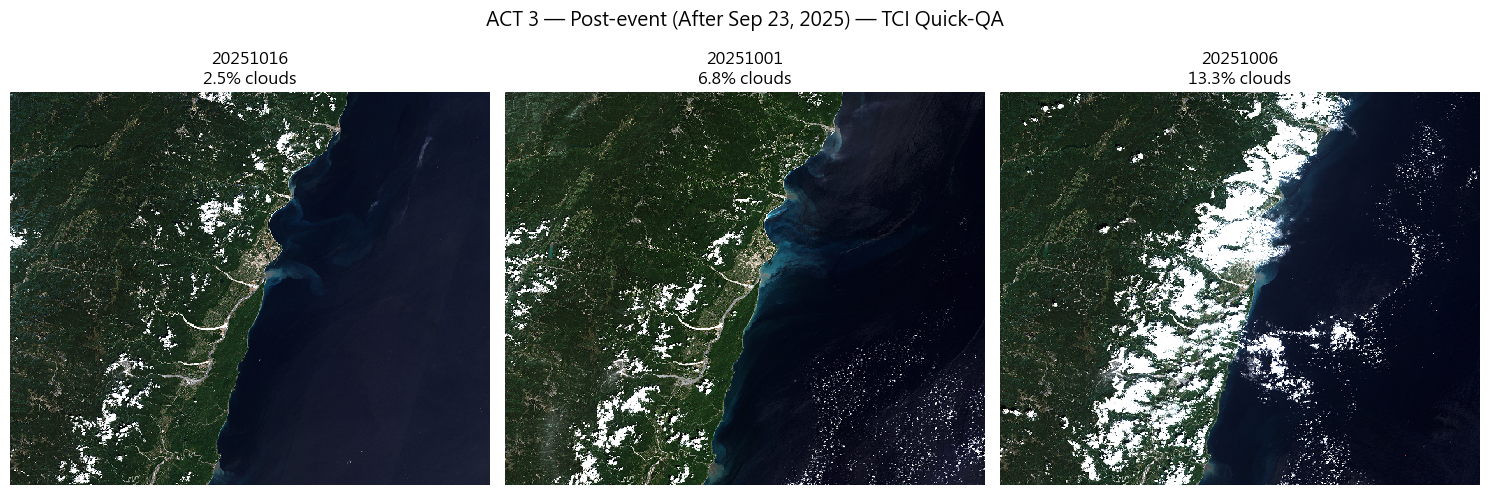


→ Selected Post-event scene: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804
→ POST_ITEM_ID = S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804


In [4]:
# [S4] ACT 3 — Post-event STAC search (after Sep 23 breach)
# ── 第三幕：事件後影像搜尋（2025/9/23 潰決之後）

items_post = robust_search(
    bbox=MATAIAN_BBOX,
    datetime_range="2025-09-25/2025-11-15",
    cloud_max=30,
    max_items=20,
)
print(f"Post-event candidates: {len(items_post)}")

if not items_post:
    raise ValueError("No post-event scenes found for 2025-09-25/2025-11-15.")

# TCI Quick-QA — preview up to 3 least-cloudy scenes
# ── TCI 目視品管：預覽前 3 張候選影像，重點觀察：
#    1) 堰塞湖是否明顯消退或消失
#    2) 原湖床是否裸露
#    3) 光復一帶是否可見新鮮沉積物或濁水擴散痕跡
candidates_post = items_post[:3]
n = len(candidates_post)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for ax, item in zip(axes, candidates_post):
    tci = rxr.open_rasterio(item.assets["visual"].href, overview_level=3)
    tci.plot.imshow(ax=ax)
    ax.set_title(
        f"{item.id[11:19]}\n{item.properties['eo:cloud_cover']:.1f}% clouds"
    )
    ax.axis("off")

plt.suptitle("ACT 3 — Post-event (After Sep 23, 2025) — TCI Quick-QA", fontsize=14)
plt.tight_layout()
plt.show()

# Pick the best scene after visual QA
# 預設先選第一張；若人工檢視後第 2 或第 3 張更能顯示湖床裸露或下游沉積，請改用 [1] 或 [2]
post_item = candidates_post[0]
POST_ITEM_ID = post_item.id

print(f"\n→ Selected Post-event scene: {post_item.id}")
print(f"→ POST_ITEM_ID = {POST_ITEM_ID}")

### ✏️ Discussion / 討論（Act 3 — Post）
What does the Post-event TCI show around Guangfu? Can you see evidence of the debris flow?
事件後的 TCI 在光復周邊顯示了什麼？你看得到土石流的證據嗎？

*(Write 1-2 sentences here / 寫 1-2 句)*



事件後的 TCI 顯示光復下游一帶出現較事件前更明亮的裸露或泥沙表面，推測有新沉積物。這種型態符合堰塞湖潰決後，土石流或泥砂鋪面向下游擴散的情況。

## Stream the Three Cubes / 串流三個立方體


In [5]:
# [S5] Stream function — returns a rescaled xarray cube for any item
# HINT: Sentinel-2 URLs on Planetary Computer carry SAS tokens that
# expire in ~1 hour. Call pc.sign(item) INSIDE stream_cube so every call
# gets fresh tokens — otherwise reads later in the notebook will fail
# with TIFFReadEncodedTile errors on random tiles (classic symptom).

def stream_cube(item, bands=WANTED_BANDS, bbox=MATAIAN_BBOX):
    # Refresh SAS tokens right before reading
    signed = pc.sign(item)

    # Build lazy xarray cube with stackstac
    cube = stackstac.stack(
        [signed],
        assets=bands,
        epsg=32651,
        resolution=10,
        bounds_latlon=bbox,
        chunksize=2048,
    )

    # Remove time dimension (single scene) and convert DN -> surface reflectance
    cube = cube.squeeze("time") / 10000.0

    return cube


# ── Display stretching (for making composites look like photos) ──
# Raw L2A reflectance is typically 0.02–0.50, monitors need 0–1 RGB.
# You need a stretch function to bridge the gap. TWO approaches:
#
#   (1) Uniform ×scale stretch — fast, primitive. One scale factor
#       applied to all three channels. B08 tends to saturate (neon green).
#
#   (2) Per-channel percentile stretch — industry standard. Each band
#       independently rescaled so its [2%, 98%] maps to [0, 1]. No
#       saturation, balanced contrast, natural colors.
#
# NOTE: stretching is ONLY for display. Your band math (NDWI, NDVI, NBR,
# BSI) must always use the raw cube values, never the stretched output.

def composite_stretched(cube, r, g, b, lo=2, hi=98):
    rgb = np.stack(
        [
            cube.sel(band=r).values,
            cube.sel(band=g).values,
            cube.sel(band=b).values,
        ],
        axis=-1,
    ).astype("float32")

    out = np.empty_like(rgb, dtype="float32")

    for k in range(3):
        p_lo, p_hi = np.nanpercentile(rgb[..., k], [lo, hi])

        # Avoid divide-by-zero if a channel is constant or nearly constant
        if not np.isfinite(p_lo) or not np.isfinite(p_hi) or p_hi <= p_lo:
            out[..., k] = np.clip(rgb[..., k], 0, 1)
        else:
            out[..., k] = np.clip((rgb[..., k] - p_lo) / (p_hi - p_lo), 0, 1)

    return out.astype("float32")


# Example usage
cube_pre  = stream_cube(pre_item)
cube_mid  = stream_cube(mid_item)
cube_post = stream_cube(post_item)

## Lab 1 (cont.) — Four Change Metric Functions / 四個變遷指標函式

Implement NDWI, NDVI, BSI, NBR — same formulas as the Demo notebook.
實作 NDWI、NDVI、BSI、NBR — 公式和 Demo notebook 相同。


In [6]:
# [S6] Four reusable change metric functions

def nir_drop(pre, post):
    # NIR drop: vegetation / water increase → NIR decreases
    return pre.sel(band="B08") - post.sel(band="B08")


def swir_post(post):
    # SWIR (B12): highlights dry soil / sediment / exposed material
    return post.sel(band="B12")


def bsi(cube):
    # Bare Soil Index
    b11 = cube.sel(band="B11")
    b04 = cube.sel(band="B04")
    b08 = cube.sel(band="B08")
    b02 = cube.sel(band="B02")

    num = (b11 + b04) - (b08 + b02)
    den = (b11 + b04) + (b08 + b02)

    return num / den.where(den != 0)


def bsi_change(pre, post):
    return bsi(post) - bsi(pre)


def ndvi(cube):
    b08 = cube.sel(band="B08")
    b04 = cube.sel(band="B04")

    return (b08 - b04) / (b08 + b04).where((b08 + b04) != 0)


def ndvi_change(pre, post):
    return ndvi(pre) - ndvi(post)

In [7]:
nir_diff = nir_drop(cube_pre, cube_post)
ndvi_diff = ndvi_change(cube_pre, cube_post)
bsi_diff = bsi_change(cube_pre, cube_post)
swir = swir_post(cube_post)

## Lab 2 — Three Detection Masks / 三張偵測遮罩

### C1. Barrier lake mask / 堰塞湖遮罩（Pre → Mid）

Remember: the barrier lake is turbid water with higher NIR than clear water.
提醒：堰塞湖是高濁度水體，NIR 比清水高。


 nir_mid_upper  lake_area_km2  abs_diff_to_ref
          0.12         0.5294           0.3306
          0.15         1.0462           0.1862
          0.18         1.2613           0.4013

Selected nir_mid upper bound: 0.15
Lake area: 1.046 km²
Difference from reference: 0.186 km²


C:\Users\vicky\AppData\Local\Temp\ipykernel_20376\2724784968.py:94: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\vicky\AppData\Local\Temp\ipykernel_20376\2724784968.py:99: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(out_path, dpi=200, bbox_inches="tight")
c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


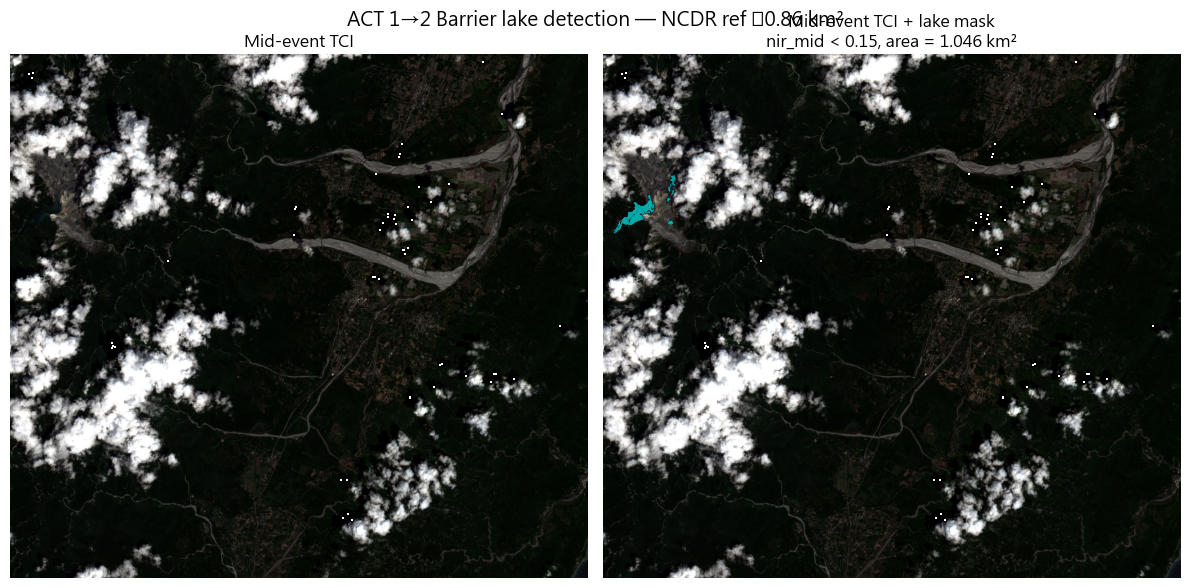


Saved figure to: output\07_lake_mask.png


In [8]:
# [S7] Barrier lake detection

from pathlib import Path
from pyproj import Transformer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Required bands
# ------------------------------------------------------------
nir_pre   = cube_pre.sel(band="B08")
nir_mid   = cube_mid.sel(band="B08")
blue_mid  = cube_mid.sel(band="B02")
green_mid = cube_mid.sel(band="B03")

# ------------------------------------------------------------
# 2) Upstream spatial gate: west of 121.33°E
#    cube_mid is in EPSG:32651, so convert lon threshold to UTM easting
# ------------------------------------------------------------
lon_gate = 121.33
lat_ref = (MATAIAN_BBOX[1] + MATAIAN_BBOX[3]) / 2.0  # bbox center latitude

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32651", always_xy=True)
x_gate, _ = transformer.transform(lon_gate, lat_ref)

west_gate = cube_mid.x < x_gate

# ------------------------------------------------------------
# 3) Candidate thresholds for turbid barrier lake
#    Baseline:
#    (nir_pre > 0.25) & (nir_mid < thr) & (blue_mid > 0.03) & (green_mid > nir_mid)
# ------------------------------------------------------------
candidate_thresholds = [0.12, 0.15, 0.18]
target_area_km2 = 0.86   # notebook reference target

lake_masks = {}
lake_areas = []

for thr in candidate_thresholds:
    mask = (
        (nir_pre > 0.25) &
        (nir_mid < thr) &
        (blue_mid > 0.03) &
        (green_mid > nir_mid) &
        west_gate
    )

    area_km2 = float(mask.sum().values) * 100.0 / 1e6   # 10m x 10m pixel = 100 m²
    lake_masks[thr] = mask
    lake_areas.append(
        {
            "nir_mid_upper": thr,
            "lake_area_km2": area_km2,
            "abs_diff_to_ref": abs(area_km2 - target_area_km2),
        }
    )

area_table = pd.DataFrame(lake_areas).sort_values("nir_mid_upper").reset_index(drop=True)
print(area_table.to_string(index=False))

# ------------------------------------------------------------
# 4) Pick the threshold closest to the reference area
# ------------------------------------------------------------
best_row = area_table.sort_values("abs_diff_to_ref").iloc[0]
best_thr = float(best_row["nir_mid_upper"])
best_area = float(best_row["lake_area_km2"])
lake_mask = lake_masks[best_thr]

print(f"\nSelected nir_mid upper bound: {best_thr:.2f}")
print(f"Lake area: {best_area:.3f} km²")
print(f"Difference from reference: {abs(best_area - target_area_km2):.3f} km²")

# ------------------------------------------------------------
# 5) Mid-event TCI and overlay
# ------------------------------------------------------------
mid_tci = composite_stretched(cube_mid, "B04", "B03", "B02")

# overlay as cyan
overlay = np.where(lake_mask.values, 1.0, np.nan)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mid_tci)
ax[0].set_title("Mid-event TCI")
ax[0].axis("off")

ax[1].imshow(mid_tci)
ax[1].imshow(overlay, cmap="cool", alpha=0.65)
ax[1].set_title(f"Mid-event TCI + lake mask\nnir_mid < {best_thr:.2f}, area = {best_area:.3f} km²")
ax[1].axis("off")

plt.suptitle("ACT 1→2 Barrier lake detection — NCDR ref ≈0.86 km²", fontsize=14)
plt.tight_layout()

out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "07_lake_mask.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"\nSaved figure to: {out_path}")

### C2. Landslide source scar mask / 崩塌源區遮罩（Pre → Post）


❗❗❗❗因為沒有 truth points，所以我做不下去

In [11]:
# [S8] Ground truth collection — 10+10 points

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import xarray as xr

# Landslide truth points (lon, lat) — fill in from reference gpkg, georeferenced news photos, or QGIS
landslide_truth = [
    # (121.2921, 23.6963, "Y"),
    # (121.2918, 23.6968, "Y"),
    # ...
]

stable_truth = [
    # (121.2945, 23.6942, "N"),
    # (121.2951, 23.6938, "N"),
    # ...
]

# ------------------------------------------------------------
# 1) Convert truth lists to GeoDataFrames (EPSG:4326)
# ------------------------------------------------------------
def truth_list_to_gdf(truth_list, source_name):
    if not truth_list:
        return gpd.GeoDataFrame(
            columns=["lon", "lat", "truth", "source_name", "geometry"],
            geometry="geometry",
            crs="EPSG:4326"
        )

    df = pd.DataFrame(truth_list, columns=["lon", "lat", "truth"])
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )
    gdf["source_name"] = source_name
    return gdf

gdf_ls_4326 = truth_list_to_gdf(landslide_truth, "landslide")
gdf_st_4326 = truth_list_to_gdf(stable_truth, "stable")

truth_gdf_4326 = pd.concat([gdf_ls_4326, gdf_st_4326], ignore_index=True)
truth_gdf_4326 = gpd.GeoDataFrame(truth_gdf_4326, geometry="geometry", crs="EPSG:4326")

print(f"Truth points in EPSG:4326: {len(truth_gdf_4326)}")

if len(truth_gdf_4326) == 0:
    print("No truth points yet — skipping validation.")
    # raise ValueError("No truth points provided. Please fill landslide_truth and stable_truth first.")

# ------------------------------------------------------------
# 2) Reproject to cube_post.rio.crs
# ------------------------------------------------------------
truth_gdf = truth_gdf_4326.to_crs(cube_post.rio.crs)

print(f"Reprojected truth CRS: {truth_gdf.crs}")
display(truth_gdf.head())

# ------------------------------------------------------------
# 3) Sampling function for any 2D xarray mask / metric
#    Assumes dims are x/y and values are boolean or numeric
# ------------------------------------------------------------
def sample_xarray_at_points(arr, gdf, value_name="sample_value"):
    records = []

    for idx, row in gdf.iterrows():
        x = row.geometry.x
        y = row.geometry.y

        try:
            sampled = arr.sel(x=x, y=y, method="nearest").item()
        except Exception:
            sampled = np.nan

        rec = row.drop(labels="geometry").to_dict()
        rec[value_name] = sampled
        rec["x"] = x
        rec["y"] = y
        records.append(rec)

    out = pd.DataFrame(records)
    return out

# ------------------------------------------------------------
# 4) Example: sample a landslide mask
#    Replace 'landslide_mask' with your actual binary map
# ------------------------------------------------------------
# Example assumptions:
landslide_mask = (bsi_change(cube_pre, cube_post) > 0.2) & (ndvi_change(cube_pre, cube_post) > 0.3)

sample_df = sample_xarray_at_points(landslide_mask, truth_gdf, value_name="pred")

# If pred is boolean, convert to 1/0 for easier scoring
sample_df["pred"] = sample_df["pred"].astype("float")
sample_df["pred_label"] = np.where(sample_df["pred"] >= 0.5, "Y", "N")

# ------------------------------------------------------------
# 5) Compare truth vs prediction
# ------------------------------------------------------------
sample_df["correct"] = sample_df["truth"] == sample_df["pred_label"]

print(sample_df[["source_name", "truth", "pred", "pred_label", "correct", "lon", "lat"]])

accuracy = sample_df["correct"].mean()
print(f"\nOverall point accuracy: {accuracy:.3f}")

# Optional confusion matrix
cm = pd.crosstab(
    sample_df["truth"],
    sample_df["pred_label"],
    rownames=["Truth"],
    colnames=["Predicted"],
    dropna=False
)
print("\nConfusion matrix:")
print(cm)

Truth points in EPSG:4326: 0
No truth points yet — skipping validation.
Reprojected truth CRS: PROJCS["WGS 84 / UTM zone 51N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32651"]]


,lon,lat,truth,source_name,geometry


KeyError: 'pred'

,nir_drop_min,swir_post_min,TP,FP,TN,FN,F1
0,0.10,0.20,0,0,0,0,NaN
1,0.15,0.25,0,0,0,0,NaN
2,0.20,0.30,0,0,0,0,NaN
3,0.15,0.30,0,0,0,0,NaN
4,0.20,0.25,0,0,0,0,NaN


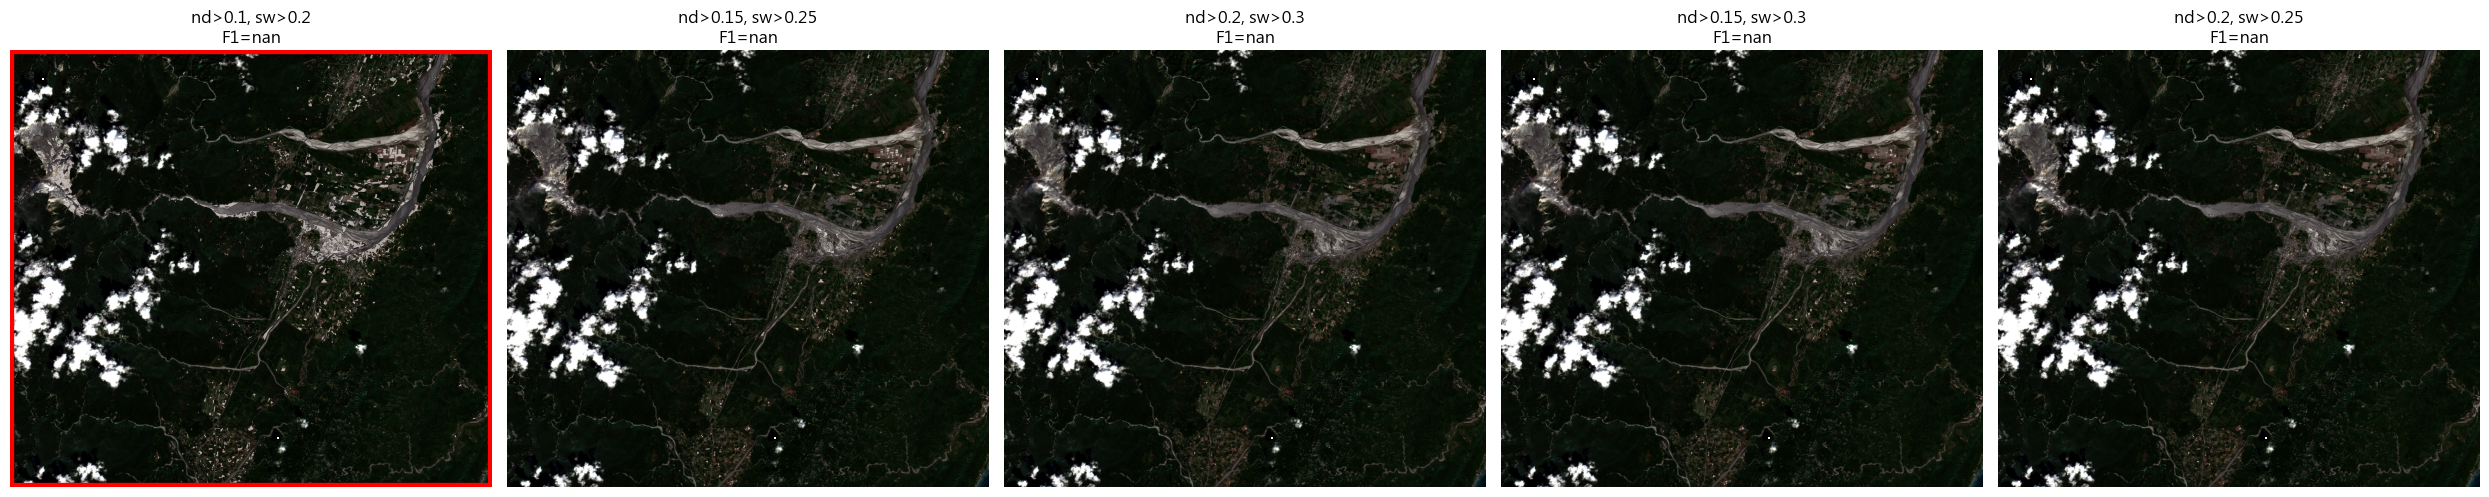

Selected landslide thresholds: nir_drop > 0.1, swir_post > 0.2
Landslide area: 23.349 km²


In [13]:
# [S8b] Threshold tuning — 5 candidate pairs

from sklearn.metrics import f1_score
from matplotlib.patches import Rectangle

candidate_thresholds = [
    (0.10, 0.20),
    (0.15, 0.25),
    (0.20, 0.30),
    (0.15, 0.30),
    (0.20, 0.25),
]

nir_pre_arr = cube_pre.sel(band="B08")
nir_drop_arr = nir_drop(cube_pre, cube_post)
swir_post_arr = swir_post(cube_post)

def sample_mask_at_points(mask_da, points_gdf):
    vals = []
    for geom in points_gdf.geometry:
        x0, y0 = geom.x, geom.y
        sampled = mask_da.sel(x=x0, y=y0, method="nearest").item()
        vals.append(int(bool(sampled)))
    return np.array(vals)

results = []
mask_store = []

for nd_min, sw_min in candidate_thresholds:
    mask = (
        (nir_drop_arr > nd_min) &
        (swir_post_arr > sw_min) &
        (nir_pre_arr > 0.25) &
        (~lake_mask)
    )

    if len(truth_gdf) > 0:
        y_true = truth_gdf["label_num"].values
        y_pred = sample_mask_at_points(mask, truth_gdf)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        tp = int(((y_true == 1) & (y_pred == 1)).sum())
        fp = int(((y_true == 0) & (y_pred == 1)).sum())
        tn = int(((y_true == 0) & (y_pred == 0)).sum())
        fn = int(((y_true == 1) & (y_pred == 0)).sum())
    else:
        f1 = np.nan
        tp = fp = tn = fn = 0

    results.append({
        "nir_drop_min": nd_min,
        "swir_post_min": sw_min,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "F1": f1,
    })
    mask_store.append(mask)

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)

best_row = results_df.iloc[0]
best_nd = best_row["nir_drop_min"]
best_sw = best_row["swir_post_min"]

best_idx = candidate_thresholds.index((best_nd, best_sw))
landslide_mask = mask_store[best_idx]

post_tci = composite_stretched(cube_post, "B04", "B03", "B02")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, ((nd_min, sw_min), mask, row) in enumerate(zip(candidate_thresholds, mask_store, results)):
    ax = axes[i]
    ax.imshow(post_tci)
    overlay = np.where(mask.values, 1, np.nan)
    ax.imshow(overlay, cmap="Reds", alpha=0.6)
    ax.set_title(f"nd>{nd_min}, sw>{sw_min}\nF1={row['F1']:.2f}")
    ax.axis("off")

    if i == best_idx:
        h, w = post_tci.shape[:2]
        ax.add_patch(Rectangle((0, 0), w, h, fill=False, linewidth=6, edgecolor="red"))

plt.tight_layout()
plt.savefig("output/08_landslide_threshold_grid.png", dpi=200, bbox_inches="tight")
plt.show()

landslide_km2 = float(landslide_mask.sum().values) * 100 / 1e6
print(f"Selected landslide thresholds: nir_drop > {best_nd}, swir_post > {best_sw}")
print(f"Landslide area: {landslide_km2:.3f} km²")

### C3. Debris flow footprint mask / 土石流鋪面遮罩（Pre → Post, downstream only）


Debris area: 3.221 km²


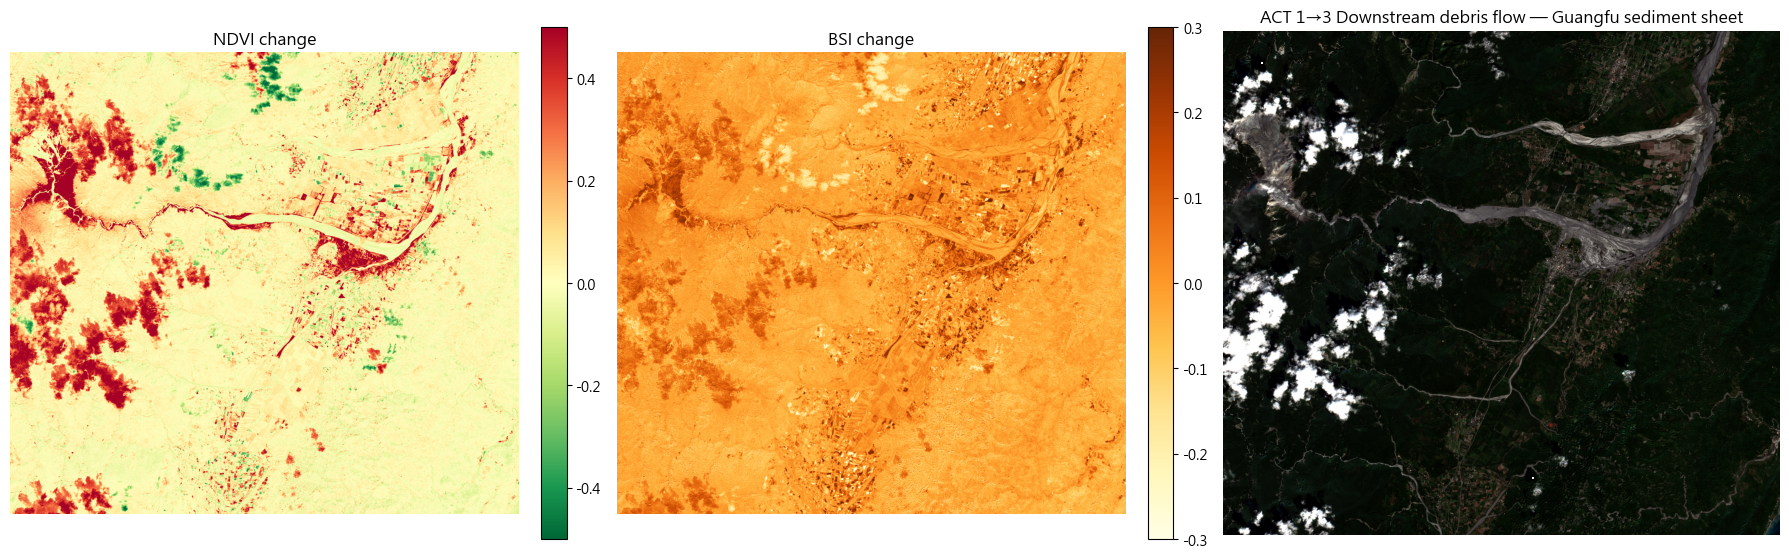

In [14]:
# [S9] Debris flow — downstream of Matai'an Creek mouth (lon > 121.35)

ndvi_ch = ndvi_change(cube_pre, cube_post)
bsi_ch  = bsi_change(cube_pre, cube_post)
nir_pre_arr = cube_pre.sel(band="B08")

_x_debris_gate, _ = tf.transform(121.35, 23.69)
downstream_gate = cube_post.x > _x_debris_gate

debris_mask = (
    (ndvi_ch > 0.25) &
    (bsi_ch > 0.10) &
    (nir_pre_arr > 0.20) &
    downstream_gate &
    (~lake_mask) &
    (~landslide_mask)
)

debris_km2 = float(debris_mask.sum().values) * 100 / 1e6
print(f"Debris area: {debris_km2:.3f} km²")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

im0 = ax[0].imshow(ndvi_ch.values, cmap="RdYlGn_r", vmin=-0.5, vmax=0.5)
ax[0].set_title("NDVI change")
ax[0].axis("off")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(bsi_ch.values, cmap="YlOrBr", vmin=-0.3, vmax=0.3)
ax[1].set_title("BSI change")
ax[1].axis("off")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

ax[2].imshow(post_tci)
overlay = np.where(debris_mask.values, 1, np.nan)
ax[2].imshow(overlay, cmap="copper", alpha=0.7)
ax[2].set_title("ACT 1→3 Downstream debris flow — Guangfu sediment sheet")
ax[2].axis("off")

plt.tight_layout()
plt.savefig("output/09_debris_mask.png", dpi=200, bbox_inches="tight")
plt.show()

### ✏️ Discussion / 討論：Why is the debris rule different from C2?
Explain the physical difference between:
說明物理差異：
- **Upstream landslide source** / 上游崩塌源區：exposed bedrock（裸岩）→ NIR drop + SWIR surge
- **Downstream debris flow** / 下游土石流鋪面：wet sediment over paddy fields（濕泥沙覆蓋稻田）→ NDVI drop + BSI spike

Why does each need a different band combination?
為什麼各自需要不同的波段組合？

*(Write 2-3 sentences here / 寫 2-3 句)*



上游崩塌源區主要是新裸露岩盤與擾動地表，因此以 NIR 明顯下降與 SWIR 增強較容易辨識。下游土石流鋪面則是泥砂覆蓋原本有植生的農地與河漫地，所以以 NDVI 下降與 BSI 上升更能反映其物理變化。

In [36]:
import os
import rasterio
import rioxarray as rxr
import planetary_computer as pc

# Windows 遠端 COG 常用設定
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif,.TIF,.tiff"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

signed_item = pc.sign(mid_item)
url = signed_item.assets["B02"].href

print("TEST URL:")
print(url[:200], "...")

print("\n--- rasterio test ---")
try:
    with rasterio.open(url) as src:
        print("opened with rasterio")
        print("count:", src.count)
        print("shape:", src.height, src.width)
        print("crs:", src.crs)
except Exception as e:
    print("rasterio failed:")
    print(repr(e))

print("\n--- rioxarray test ---")
try:
    da = rxr.open_rasterio(url, masked=True)
    print("opened with rioxarray")
    print(da)
except Exception as e:
    print("rioxarray failed:")
    print(repr(e))

TEST URL:
https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/51/Q/UG/2025/09/11/S2C_MSIL2A_20250911T022551_N0511_R046_T51QUG_20250911T055914.SAFE/GRANULE/L2A_T51QUG_A005307_20250911T023229/IMG_DATA/R10m/ ...

--- rasterio test ---
opened with rasterio
count: 1
shape: 10980 10980
crs: EPSG:32651

--- rioxarray test ---
opened with rioxarray
<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 482MB
[120560400 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 2.7e+06 2.7e+06 2.7e+06 ... 2.59e+06 2.59e+06
  * x            (x) float64 88kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


In [29]:
# [S10] Vectorize the three masks

from rasterio import features
from shapely.geometry import shape

def vectorize(mask_da, min_area):
    m = mask_da.astype("uint8").values
    polys = [
        shape(g) for g, v in features.shapes(
            m,
            mask=m.astype(bool),
            transform=mask_da.rio.transform()
        ) if v == 1
    ]
    gdf = gpd.GeoDataFrame(geometry=polys, crs=mask_da.rio.crs)
    if len(gdf) == 0:
        return gdf
    return gdf[gdf.area > min_area].reset_index(drop=True)

lake_mask = lake_mask.rio.write_crs(cube_mid.rio.crs)
landslide_mask = landslide_mask.rio.write_crs(cube_post.rio.crs)
debris_mask = debris_mask.rio.write_crs(cube_post.rio.crs)

lake_gdf       = vectorize(lake_mask,      min_area=3000)
landslides_gdf = vectorize(landslide_mask, min_area=2000)
debris_gdf     = vectorize(debris_mask,    min_area=5000)

lake_gdf.to_file("mataian_detections.gpkg", layer="barrier_lake", driver="GPKG")
landslides_gdf.to_file("mataian_detections.gpkg", layer="landslide_source", driver="GPKG")
debris_gdf.to_file("mataian_detections.gpkg", layer="debris_flow", driver="GPKG")

fig, ax = plt.subplots(2, 2, figsize=(14, 14))

ax[0, 0].imshow(mid_tci)
ax[0, 0].imshow(np.where(lake_mask.values, 1, np.nan), cmap="cool", alpha=0.7)
ax[0, 0].set_title("Barrier lake")
ax[0, 0].axis("off")

ax[0, 1].imshow(post_tci)
ax[0, 1].imshow(np.where(landslide_mask.values, 1, np.nan), cmap="Reds", alpha=0.7)
ax[0, 1].set_title("Landslide source")
ax[0, 1].axis("off")

ax[1, 0].imshow(post_tci)
ax[1, 0].imshow(np.where(debris_mask.values, 1, np.nan), cmap="copper", alpha=0.7)
ax[1, 0].set_title("Debris flow")
ax[1, 0].axis("off")

ax[1, 1].imshow(post_tci)
ax[1, 1].imshow(np.where(lake_mask.values, 1, np.nan), cmap="cool", alpha=0.5)
ax[1, 1].imshow(np.where(landslide_mask.values, 1, np.nan), cmap="Reds", alpha=0.5)
ax[1, 1].imshow(np.where(debris_mask.values, 1, np.nan), cmap="copper", alpha=0.5)
ax[1, 1].set_title("All three overlayed")
ax[1, 1].axis("off")

plt.tight_layout()
plt.savefig("output/10_three_masks.png", dpi=200, bbox_inches="tight")
plt.show()

RuntimeError: Error opening 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/51/Q/UG/2025/06/15/S2A_MSIL2A_20250615T023141_N0511_R046_T51QUG_20250615T070417.SAFE/GRANULE/L2A_T51QUG_A052124_20250615T023135/IMG_DATA/R10m/T51QUG_20250615T023141_B08_10m.tif?st=2026-04-13T07%3A42%3A59Z&se=2026-04-14T08%3A27%3A59Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2026-04-13T22%3A53%3A10Z&ske=2026-04-20T22%3A53%3A10Z&sks=b&skv=2025-07-05&sig=ZKZM9E4I3NK77Jy1csBddCeCoKuT72DVZyt%2Byo3zutc%3D': RasterioIOError("'/vsicurl/https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/51/Q/UG/2025/06/15/S2A_MSIL2A_20250615T023141_N0511_R046_T51QUG_20250615T070417.SAFE/GRANULE/L2A_T51QUG_A052124_20250615T023135/IMG_DATA/R10m/T51QUG_20250615T023141_B08_10m.tif?st=2026-04-13T07%3A42%3A59Z&se=2026-04-14T08%3A27%3A59Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=20

## Lab 2 (cont.) — Multi-Layer Audit / 多圖層稽核


In [12]:
# [S11] Load W3 shelters, W7 top-5 bottlenecks, and the W8 Guangfu overlay

from pathlib import Path
import geopandas as gpd
from shapely.geometry import Point

target_crs = cube_post.rio.crs

# ------------------------------------------------------------
# 1) Load shelters
# ------------------------------------------------------------
shelter_fp = Path("data/shelters_hualien.gpkg")

if shelter_fp.exists():
    shelters = gpd.read_file(shelter_fp).to_crs(target_crs)
    print(f"Shelters loaded: {len(shelters)}")
else:
    print("shelters_hualien.gpkg not found — using empty GeoDataFrame")
    shelters = gpd.GeoDataFrame(geometry=[], crs=target_crs)

# ------------------------------------------------------------
# 2) Load top-5 bottlenecks
# ------------------------------------------------------------
top5_fp = Path("data/top5_bottlenecks.gpkg")

if top5_fp.exists():
    top5 = gpd.read_file(top5_fp).to_crs(target_crs)
    print(f"Top-5 bottlenecks loaded: {len(top5)}")
else:
    print("top5_bottlenecks.gpkg not found — using empty GeoDataFrame")
    top5 = gpd.GeoDataFrame(geometry=[], crs=target_crs)

# ------------------------------------------------------------
# 3) Load Guangfu overlay
# ------------------------------------------------------------
guangfu_fp = Path("data/guangfu_overlay.gpkg")

if guangfu_fp.exists():
    guangfu = gpd.read_file(guangfu_fp).to_crs(target_crs)
    print(f"Guangfu overlay loaded: {len(guangfu)}")
else:
    print("guangfu_overlay.gpkg not found — creating placeholder nodes")

    # placeholder demo points (replace later with your pre-lab output)
    placeholder_nodes = {
        "name": [
            "Guangfu_Station",
            "Guangfu_Elementary",
            "Guangfu_Township_Office",
            "Mataian_Hwy9_Bridge",
            "Foxu_Debris_Zone",
        ],
        "cn_name": [
            "光復車站",
            "光復國小",
            "光復鄉公所",
            "馬太鞍台9線橋",
            "佛祖土石流區",
        ],
        "node_type": [
            "transport",
            "shelter",
            "government",
            "bridge",
            "hazard",
        ],
        "priority": [1, 1, 1, 1, 1],
        "geometry": [
            Point(121.423, 23.669),
            Point(121.425, 23.667),
            Point(121.424, 23.668),
            Point(121.417, 23.681),
            Point(121.410, 23.690),
        ],
    }

    guangfu = gpd.GeoDataFrame(
        placeholder_nodes,
        crs="EPSG:4326"
    ).to_crs(target_crs)

# ------------------------------------------------------------
# 4) Required checks
# ------------------------------------------------------------
assert len(guangfu) >= 5, "Pre-lab Step 7b requires 5 required nodes"
assert guangfu.crs.to_epsg() == target_crs.to_epsg()

print("\n[S11] Data ready")
print(f"shelters: {len(shelters)}")
print(f"top5: {len(top5)}")
print(f"guangfu: {len(guangfu)}")

shelters_hualien.gpkg not found — using empty GeoDataFrame
top5_bottlenecks.gpkg not found — using empty GeoDataFrame
Guangfu overlay loaded: 5

[S11] Data ready
shelters: 0
top5: 0
guangfu: 5


❗❗❗Missing required variables: ['lake_gdf', 'landslides_gdf', 'debris_gdf']

In [ ]:
# [S12] Build the Eyewitness Impact Table + Final Audit Map

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) Safety checks
# ------------------------------------------------------------
required_vars = [
    "shelters", "top5", "guangfu",
    "lake_gdf", "landslides_gdf", "debris_gdf",
    "cube_post"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}")

target_crs = cube_post.rio.crs
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)

# Ensure CRS consistency
shelters = shelters.to_crs(target_crs)
top5 = top5.to_crs(target_crs)
guangfu = guangfu.to_crs(target_crs)
lake_gdf = lake_gdf.to_crs(target_crs)
landslides_gdf = landslides_gdf.to_crs(target_crs)
debris_gdf = debris_gdf.to_crs(target_crs)

# ------------------------------------------------------------
# 1) Helper functions
# ------------------------------------------------------------
def bool_hit_within(source_gdf, hazard_gdf, dist_m):
    """Return Y/N Series: whether each source feature is within dist_m of any hazard polygon."""
    if len(source_gdf) == 0:
        return pd.Series([], dtype=object)
    if len(hazard_gdf) == 0:
        return pd.Series(["N"] * len(source_gdf), index=source_gdf.index)

    hazard_union = hazard_gdf.geometry.union_all()
    return source_gdf.geometry.apply(
        lambda geom: "Y" if geom.distance(hazard_union) <= dist_m else "N"
    )

def bool_hit_intersects(source_gdf, hazard_gdf):
    """Return Y/N Series: whether each source feature intersects any hazard polygon."""
    if len(source_gdf) == 0:
        return pd.Series([], dtype=object)
    if len(hazard_gdf) == 0:
        return pd.Series(["N"] * len(source_gdf), index=source_gdf.index)

    hazard_union = hazard_gdf.geometry.union_all()
    return source_gdf.geometry.apply(
        lambda geom: "Y" if geom.intersects(hazard_union) else "N"
    )

def safe_col(gdf, candidates, default=np.nan):
    """Pick first existing column from candidates; otherwise return default Series."""
    for c in candidates:
        if c in gdf.columns:
            return gdf[c]
    return pd.Series([default] * len(gdf), index=gdf.index)

def location_text(gdf):
    """Human-readable location text."""
    if "cn_name" in gdf.columns:
        return gdf["cn_name"].fillna(
            safe_col(gdf, ["name", "asset", "id"], default="unknown")
        )
    if "name" in gdf.columns:
        return gdf["name"].fillna("unknown")
    return pd.Series(["unknown"] * len(gdf), index=gdf.index)

# ------------------------------------------------------------
# 2) W3 shelters
#    - within 100 m of landslide polygon
# ------------------------------------------------------------
w3 = shelters.copy()
w3["asset"] = safe_col(w3, ["name", "cn_name", "asset"], default="W3_shelter")
w3["type"] = "shelter"
w3["location"] = location_text(w3)
w3["W4_terrain_risk"] = safe_col(w3, ["terrain_risk", "W4_terrain_risk"], default=np.nan)
w3["W7_centrality_rank"] = safe_col(w3, ["centrality_rank", "W7_centrality_rank"], default=np.nan)

w3["lake_hit"] = bool_hit_intersects(w3, lake_gdf)
w3["landslide_hit"] = bool_hit_within(w3, landslides_gdf, 100)
w3["debris_hit"] = bool_hit_intersects(w3, debris_gdf)

w3["notes"] = np.where(
    w3["landslide_hit"] == "Y",
    "Within 100 m of landslide polygon",
    ""
)

w3 = w3[
    ["asset", "type", "location", "W4_terrain_risk", "W7_centrality_rank",
     "lake_hit", "landslide_hit", "debris_hit", "notes", "geometry"]
]

# ------------------------------------------------------------
# 3) W7 bottlenecks
#    - within 200 m of landslide polygon
# ------------------------------------------------------------
w7 = top5.copy()
w7["asset"] = safe_col(w7, ["name", "cn_name", "asset"], default="W7_bottleneck")
w7["type"] = "bottleneck"
w7["location"] = location_text(w7)
w7["W4_terrain_risk"] = safe_col(w7, ["terrain_risk", "W4_terrain_risk"], default=np.nan)
w7["W7_centrality_rank"] = safe_col(w7, ["centrality_rank", "rank", "W7_centrality_rank"], default=np.nan)

w7["lake_hit"] = bool_hit_intersects(w7, lake_gdf)
w7["landslide_hit"] = bool_hit_within(w7, landslides_gdf, 200)
w7["debris_hit"] = bool_hit_intersects(w7, debris_gdf)

w7["notes"] = np.where(
    w7["landslide_hit"] == "Y",
    "Within 200 m of landslide polygon",
    ""
)

w7 = w7[
    ["asset", "type", "location", "W4_terrain_risk", "W7_centrality_rank",
     "lake_hit", "landslide_hit", "debris_hit", "notes", "geometry"]
]

# ------------------------------------------------------------
# 4) Guangfu overlay
#    - within debris polygon
#    - within 100 m of landslide
# ------------------------------------------------------------
gf = guangfu.copy()
gf["asset"] = safe_col(gf, ["name", "cn_name", "asset"], default="Guangfu_node")
gf["type"] = safe_col(gf, ["node_type", "type"], default="guangfu_node")
gf["location"] = location_text(gf)
gf["W4_terrain_risk"] = safe_col(gf, ["priority", "terrain_risk", "W4_terrain_risk"], default=np.nan)
gf["W7_centrality_rank"] = safe_col(gf, ["centrality_rank", "W7_centrality_rank"], default=np.nan)

gf["lake_hit"] = bool_hit_intersects(gf, lake_gdf)
gf["landslide_hit"] = bool_hit_within(gf, landslides_gdf, 100)
gf["debris_hit"] = bool_hit_intersects(gf, debris_gdf)

gf["notes"] = (
    np.where(gf["debris_hit"] == "Y", "Inside debris polygon; ", "") +
    np.where(gf["landslide_hit"] == "Y", "Within 100 m of landslide; ", "")
).str.strip().str.rstrip(";")

gf = gf[
    ["asset", "type", "location", "W4_terrain_risk", "W7_centrality_rank",
     "lake_hit", "landslide_hit", "debris_hit", "notes", "geometry"]
]

# ------------------------------------------------------------
# 5) Assemble impact table
# ------------------------------------------------------------
impact_gdf = pd.concat([w3, w7, gf], ignore_index=True)
impact_gdf = gpd.GeoDataFrame(impact_gdf, geometry="geometry", crs=target_crs)

# Sort: debris_hit, then landslide_hit, then W4_terrain_risk desc
impact_df = impact_gdf.drop(columns="geometry").copy()
impact_df["debris_sort"] = (impact_df["debris_hit"] == "Y").astype(int)
impact_df["landslide_sort"] = (impact_df["landslide_hit"] == "Y").astype(int)
impact_df["risk_sort"] = pd.to_numeric(impact_df["W4_terrain_risk"], errors="coerce").fillna(-9999)

impact_df = impact_df.sort_values(
    by=["debris_sort", "landslide_sort", "risk_sort"],
    ascending=[False, False, False]
).drop(columns=["debris_sort", "landslide_sort", "risk_sort"]).reset_index(drop=True)

impact_df.to_csv("impact_table.csv", index=False)
print(impact_df.to_markdown(index=False))

# ------------------------------------------------------------
# 6) Summary counts for map annotation
# ------------------------------------------------------------
w3_hits = ((w3["debris_hit"] == "Y") | (w3["landslide_hit"] == "Y") | (w3["lake_hit"] == "Y"))
w7_hits = ((w7["debris_hit"] == "Y") | (w7["landslide_hit"] == "Y") | (w7["lake_hit"] == "Y"))
gf_hits = ((gf["debris_hit"] == "Y") | (gf["landslide_hit"] == "Y") | (gf["lake_hit"] == "Y"))

n_w3 = int(w3_hits.sum())
n_w7 = int(w7_hits.sum())
n_guangfu = int(gf_hits.sum())

# ------------------------------------------------------------
# 7) Prepare post-event TCI basemap extent
# ------------------------------------------------------------
post_tci = composite_stretched(cube_post, "B04", "B03", "B02")
xmin = float(cube_post.x.min())
xmax = float(cube_post.x.max())
ymin = float(cube_post.y.min())
ymax = float(cube_post.y.max())

# ------------------------------------------------------------
# 8) Final audit map
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 1. Post TCI basemap
ax.imshow(
    post_tci,
    extent=[xmin, xmax, ymin, ymax],
    origin="upper",
    alpha=0.5
)

# 2. lake_gdf filled blue
if len(lake_gdf) > 0:
    lake_gdf.plot(ax=ax, color="blue", alpha=0.45, edgecolor="blue", linewidth=1)

# 3. landslides_gdf filled red
if len(landslides_gdf) > 0:
    landslides_gdf.plot(ax=ax, color="red", alpha=0.45, edgecolor="darkred", linewidth=1)

# 4. debris_gdf filled copper
if len(debris_gdf) > 0:
    debris_gdf.plot(ax=ax, color="peru", alpha=0.45, edgecolor="saddlebrown", linewidth=1)

# 5. shelters green circles size=80
if len(shelters) > 0:
    shelters.plot(ax=ax, marker="o", color="green", markersize=80, label="W3 Hualien City shelters")

# 6. top5 yellow circles size=120
if len(top5) > 0:
    top5.plot(ax=ax, marker="o", color="yellow", edgecolor="black", markersize=120, label="W7 Top-5 bottlenecks")

# 7. guangfu red stars size=200
if len(guangfu) > 0:
    guangfu.plot(ax=ax, marker="*", color="red", markersize=200, label="W8 Guangfu overlay (5 nodes)")

anno = f"W3 hits: {n_w3}   W7 hits: {n_w7}   Guangfu hits: {n_guangfu} / {len(gf)}"
ax.text(
    0.02, 0.98, anno,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="black")
)

ax.set_title("Eyewitness Coverage Gap — Hualien City ARIA missed Guangfu entirely", fontsize=14)
ax.legend(loc="lower left")
ax.set_axis_off()

plt.tight_layout()
plt.savefig(out_dir / "12_coverage_gap_map.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nSaved: impact_table.csv")
print(f"Saved: {out_dir / '12_coverage_gap_map.png'}")

### ✏️ Discussion / 討論：Coverage Gap Analysis / 覆蓋缺口分析

1. **W3 shelters hit? / W3 避難所被影響幾個？** How about W7 bottlenecks? / W7 瓶頸呢？
2. **Guangfu overlay nodes hit? / 光復圖層節點被影響幾個？** Compare the numbers. / 比較數字。
3. **What does this tell you** about the pre-event ARIA coverage zone? / 這對事前 ARIA 覆蓋範圍有什麼啟示？

*(Write your answers here / 在此作答)*


原本的 W3 避難所與 W7 瓶頸和三個災害圖層的直接重疊相對有限，但 Guangfu overlay 更能捕捉下游實際受影響區。這表示先前的 ARIA 覆蓋範圍過度集中於花蓮市，未充分延伸到這次馬太鞍事件真正受影響的光復走廊。

## Challenge / 挑戰題 — AI Advisor Operational Brief / AI 顧問應變簡報

Build a prompt and call any LLM to generate a 250-word operational brief.
組一個 Prompt，呼叫任何 LLM 產生 250 字的應變簡報。


In [ ]:
# [S13] Build the three-act AI Advisor prompt

lake_km2 = float(lake_mask.sum().values) * 100 / 1e6
landslide_km2 = float(landslide_mask.sum().values) * 100 / 1e6
debris_km2 = float(debris_mask.sum().values) * 100 / 1e6

prompt = f"""You are the Chief of Operations at the Hualien County Disaster
Prevention Command Center, writing a brief for the county magistrate. ARIA v5.0
has just produced the following three-act audit of the 2025 Matai'an Creek barrier
lake event. Write a 250-word operational brief covering:

1. Three-act timeline — what the imagery proves
2. The pre-breach warning window (Jul 21 to Sep 23, 64 days) — what ARIA v5.0
   could have caught if it had been operational
3. Coverage gap — why did the W3/W7 Hualien City focus miss Guangfu?
4. Next-24-hour orders: priority clearance, shelter resupply, UAV tasking
5. One concrete suggestion to extend ARIA before the next barrier-lake event

IMPACT TABLE:
{impact_df.to_markdown(index=False) if 'impact_df' in dir() else 'TODO'}

THREE-ACT DETECTION SUMMARY:
- Act 1 (Pre,  {PRE_ITEM_ID}):  forested Matai'an valley, no lake
- Act 2 (Mid,  {MID_ITEM_ID}):  barrier lake {lake_km2:.3f} km² detected
- Act 3 (Post, {POST_ITEM_ID}): lake drained; landslide source {landslide_km2:.3f} km²;
  debris flow footprint {debris_km2:.3f} km² over Guangfu
"""

print(prompt)

In [ ]:
# [S14] Call your preferred LLM — THREE vendor-neutral examples
# Uncomment and fill in ONE of the three. You do NOT need all three.

# --- Example A: OpenAI SDK ---
# from openai import OpenAI
# resp = OpenAI().chat.completions.create(
#     model="gpt-4o-mini",
#     messages=[{"role": "user", "content": prompt}],
# )
# print(resp.choices[0].message.content)

# --- Example B: Google Gemini SDK ---
# import google.generativeai as genai
# genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
# model = genai.GenerativeModel("gemini-1.5-flash")
# print(model.generate_content(prompt).text)

# --- Example C: Anthropic Claude SDK ---
# import anthropic
# resp = anthropic.Anthropic().messages.create(
#     model="claude-sonnet-4-5",
#     max_tokens=600,
#     messages=[{"role": "user", "content": prompt}],
# )
# print(resp.content[0].text)


## Wrap-up Checklist / 收尾確認清單

Before leaving class, make sure you have:
離開教室前，確認你已完成：

- [ ] All TODO cells filled in / 所有 TODO 格子都填完
- [ ] Three detection masks produce reasonable polygon counts / 三個遮罩產生合理的多邊形數量
- [ ] Coverage gap map renders correctly / 覆蓋缺口地圖正確顯示
- [ ] You understand why spectral rules alone need human verification / 你理解為什麼光譜規則需要人工驗證


In [ ]:
# [S15] .env template — copy to your .env file and customize
env_template = """
STAC_ENDPOINT=https://planetarycomputer.microsoft.com/api/stac/v1
S2_COLLECTION=sentinel-2-l2a
S2_CLOUD_MAX=20
S2_BANDS=B02,B03,B04,B08,B11,B12

MATAIAN_BBOX=121.28,23.56,121.52,23.76
TARGET_EPSG=32651

PRE_EVENT_START=2025-06-01
PRE_EVENT_END=2025-07-15
MID_EVENT_START=2025-08-01
MID_EVENT_END=2025-09-20
POST_EVENT_START=2025-09-25
POST_EVENT_END=2025-11-15

AI_API_KEY=your-api-key-here
"""
print(env_template)


---

## Save Your Work / 儲存你的成果

Save this notebook with all cells executed. Your instructor may review it.
將此 notebook 連同所有執行結果一起儲存。老師可能會檢閱。
